# Data Analysis 1: Pandas, Matplotlib, Seaborn, Scipy

In [5]:
# Import libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats as stats
import seaborn as sns
from datetime import datetime, timedelta

In [6]:
# Read DataFrame
df = pd.read_csv('./data/raw/games.csv',sep=',',header=0)

# Show DataFrame
print(df.head(3))

# Read Excel file
df1 = pd.read_excel('./data/raw/population.xlsx', sheet_name='Sheet1', header=None, names=['Country','Population'])

                name platform    year     genre  sales
0         Wii Sports      Wii  2006.0    Sports  41.36
1  Super Mario Bros.      NES  1985.0  Platform  29.08
2     Mario Kart Wii      Wii  2008.0    Racing  15.68


In [7]:
# Save DataFrame
file_name = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
df1.to_csv(f'data/processed/factLecturas_{file_name}.csv', index=False)

In [8]:
# DataFrame information
df.info()

# DataFrame statistics
print(df.describe())

# DataFrame statistics per column
print(df.describe(include='all'))
# include='all' allows us to see statistics for all columns, including non-numeric ones

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      16713 non-null  object 
 1   platform  16715 non-null  object 
 2   year      16446 non-null  float64
 3   genre     16713 non-null  object 
 4   sales     16715 non-null  float64
dtypes: float64(2), object(3)
memory usage: 653.1+ KB
               year         sales
count  16446.000000  16715.000000
mean    2006.484616      0.263377
std        5.877050      0.813604
min     1980.000000      0.000000
25%     2003.000000      0.000000
50%     2007.000000      0.080000
75%     2010.000000      0.240000
max     2016.000000     41.360000
                               name platform          year   genre  \
count                         16713    16715  16446.000000   16713   
unique                        11559       31           NaN      12   
top     Need for Speed: Most Wanted      PS2     

In [9]:
# DataFrame shape
print(df.shape)

# DataFrame columns
print(df.columns)

# DataFrame columns types
print(df.dtypes)

# DataFrame sample
print(df.sample(3, random_state=0))

# DataFrame tail
print(df.tail(3))

(16715, 5)
Index(['name', 'platform', 'year', 'genre', 'sales'], dtype='object')
name         object
platform     object
year        float64
genre        object
sales       float64
dtype: object
                               name platform    year   genre  sales
7634   Press Your Luck 2010 Edition       DS  2009.0    Misc   0.18
13771                     Aeon Flux      PS2  2005.0  Action   0.02
3051   Castlevania: Lords of Shadow     X360  2010.0  Action   0.42
                          name platform    year       genre  sales
16712  Haitaka no Psychedelica      PSV  2016.0   Adventure   0.00
16713         Spirits & Spells      GBA  2003.0    Platform   0.01
16714      Winning Post 8 2016      PSV  2016.0  Simulation   0.00


In [10]:
# Verify null values per column
print(df.isna().sum())

# Fill null values
df['name'] = df['name'].fillna('Unknown')
df['name'].isna().sum()

name          2
platform      0
year        269
genre         2
sales         0
dtype: int64


0

In [11]:
# Show unique values
print(df['platform'].unique())

# Count unique values
print(df['platform'].nunique())

['Wii' 'NES' 'GB' 'DS' 'X360' 'PS3' 'PS2' 'SNES' 'GBA' 'PS4' '3DS' 'N64'
 'PS' 'XB' 'PC' '2600' 'PSP' 'XOne' 'WiiU' 'GC' 'GEN' 'DC' 'PSV' 'SAT'
 'SCD' 'WS' 'NG' 'TG16' '3DO' 'GG' 'PCFX']
31


In [12]:
# Count values in column
df['platform'].value_counts()

platform
PS2     2161
DS      2151
PS3     1331
Wii     1320
X360    1262
PSP     1209
PS      1197
PC       974
XB       824
GBA      822
GC       556
3DS      520
PSV      430
PS4      392
N64      319
XOne     247
SNES     239
SAT      173
WiiU     147
2600     133
NES       98
GB        98
DC        52
GEN       29
NG        12
SCD        6
WS         6
3DO        3
TG16       2
GG         1
PCFX       1
Name: count, dtype: int64

Extracting rows or columns from DataFrame. Columns or rows are pandas series (pd.Series).

In [13]:
# Extract info by column
df.loc[:,['name','platform']]

# Extract info by column and row
df.loc[0:3,['name','platform']]

# Extract info in consecutive columns
df.loc[0:3,'name':'year']

,name,platform,year
0,Wii Sports,Wii,2006.0
1,Super Mario Bros.,NES,1985.0
2,Mario Kart Wii,Wii,2008.0
3,Wii Sports Resort,Wii,2009.0


In [14]:
# Extract info of first row, both commands are equivalent
# Extract info of row 1
df.loc[0,:]

# Extract info of row 1 with iloc
df.iloc[0,:]

name        Wii Sports
platform           Wii
year            2006.0
genre           Sports
sales            41.36
Name: 0, dtype: object

In [15]:
# An extraction of a row is a pandas Series, with columns names as index and row values as values
print(type(df.loc[0,:]))

<class 'pandas.core.series.Series'>


In [16]:
# Extract info by column with iloc. iloc is used for index positions
# Extract info by column and row
df.iloc[0:3,0:2]

# Extract info in consecutive columns
df.iloc[0:3,[0,2]]

,name,year
0,Wii Sports,2006.0
1,Super Mario Bros.,1985.0
2,Mario Kart Wii,2008.0


In [17]:
# Extract cell value
df.iloc[0,0]

'Wii Sports'

In [18]:
# Rename columns
df = df.rename(columns={'name':'Game_Name','platform':'Game_Platform'})

df = df.rename(columns={'Game_Name':'name','Game_Platform':'platform'})

## Cleaning

In [19]:
# Read DataFrame
df = pd.read_csv('./data/raw/games.csv',sep=',',header=0)

In [20]:
# Delete all row duplicates
df = df.drop_duplicates()

# Delete row duplicates based on specific columns
df = df.drop_duplicates(subset=['name','platform'])

# Count duplicates
df.duplicated(subset=['name','platform']).sum()

0

In [21]:
# Replace values
df['platform'] = df['platform'].replace({'PS4_old':'PlayStation 4_new', 'XOne_old':'Xbox One_new'})

# Change the 'nes' values by 'other', in column 'user_score'
df['platform'] = df['platform'].replace({'nes': 'other'})

In [22]:
def strip_lower_replace(element):
    '''Function to format data'''
    element = element.strip().lower().replace(" ","_").replace(",","")
    element = element.replace(";","").replace(".","")
    return element

# Loop to change column names
col_names = []
for old_name in df.columns:
    new_name = strip_lower_replace(old_name)
    col_names.append(new_name)
df.columns = col_names

# Change column types
df[['name','platform','genre']] = df[['name','platform','genre']].astype('str')

# Format column value
df['name'] = df['name'].apply(strip_lower_replace)

# Format values in some columns
for col in ['name','platform','genre']:
    df[col] = df[col].apply(strip_lower_replace)

In [23]:
# Fill null values
for col in ['name','platform','genre']:
    df[col] = df[col].fillna('unknown')

In [24]:
print(df.columns)

Index(['name', 'platform', 'year', 'genre', 'sales'], dtype='object')


In [25]:
# Axis=0 is for rows, axis=1 is for columns
# Delete all rows with null values in some columns
df = df.dropna(subset=['year'])

# Delete all columns with null values
df = df.dropna(axis=1)

# Delete column 'year' if it has null values
df = df.drop(labels=['year'], axis='columns')

df = pd.read_csv('./data/raw/games.csv',sep=',',header=0)

In [26]:
def group_plat(category: str) -> str:
    '''Function to categorize 'platform' column content'''
    if category in ['3ds','ds','gb','gba','gc','n64','nes','snes','wii','wiiu']:
        return "Nintendo"
    if category in ['pc','pcfx']:
        return "PC"
    else:
        return "Other"

# Create a new column of categories of platforms
df['platform_group'] = df['platform'].apply(group_plat)

In [27]:
# Delete duplicates
# duplicate_users = df.groupby('user_id')['group'].unique()
# df2 = df2[~df2['user_id'].isin(duplicate_users)]
# duplicate_users = duplicate_users[duplicate_users > 1].index

In [28]:
print(df.columns)

Index(['name', 'platform', 'year', 'genre', 'sales', 'platform_group'], dtype='object')


## Dates

In [29]:
# Read DataFrame
df = pd.read_csv('./data/raw/megaline_users.csv',sep=',',header=0)
print(df.head(3))

   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   

         date      plan churn_date  
0  2018-12-24  ultimate        NaN  
1  2018-08-13      surf        NaN  
2  2018-10-21      surf        NaN  


In [30]:
# Change date column to datetime
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

# Add column of churn date
df['churn_date'] = pd.to_datetime('2023-01-01') + pd.to_timedelta(np.random.randint(0, 365, size=len(df)), unit='d')
print(df.head(3))

   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   

        date      plan churn_date  
0 2018-12-24  ultimate 2023-12-10  
1 2018-08-13      surf 2023-04-25  
2 2018-10-21      surf 2023-02-13  


In [31]:
# Extract day, month and year from date
df_d = df['date'].dt.day
df_m = df['date'].dt.month
df_y = df['date'].dt.year
print(df_m.head(2))

0    12
1     8
Name: date, dtype: int32


In [32]:
# Obtain today date and time
today = pd.to_datetime('now')
print(today)
print(type(today))
print(today.year)

2025-10-29 18:13:06.167560
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
2025


## Filters

In [33]:
df = pd.read_csv('./data/raw/games.csv',sep=',',header=0)
print(df.columns)

Index(['name', 'platform', 'year', 'genre', 'sales'], dtype='object')


In [34]:
# Filter
df = df[df['year']>2015]

df = df[(df['year']>2015) | (df['year']<=2020)]

# Filter by index
df = df[df.index>93]

In [35]:
# ~ is used to invert the filter result
# Filter by not null values in column 'name' and year greater than 2015
df1 = df[(~df['name'].isna()) & (df['year']>2015)]

In [36]:
# where() verifies if a condition is False cell by cell and then, the value is substituted by the new one
# Set 'other' if the value is not in 'my_list'
my_list = ['a','b','c']
df1['cond'] = df1['name'].where(df1['name'].isin(my_list),'other')
print(df1['cond'][0:2])

94     other
108    other
Name: cond, dtype: object


In [37]:
df = pd.read_csv('./data/raw/megaline_users.csv',sep=',',header=0)
print(df.columns)

Index(['user_id', 'first_name', 'last_name', 'age', 'city', 'date', 'plan',
       'churn_date'],
      dtype='object')


In [38]:
# Fill string 'nan' by 'other' in column 'city'
df.loc[df['city'] == 'nan', 'city'] = 'other'

# Extract samples
action = df[df['plan'] == 'action']['age']
sport = df[df['plan'] == 'sports']['age']

In [39]:
# Apply a function to the Dataframe to obtain a new column
def income_monthly(row):
    if row['plan'] == 'surf':
        return 2*row['age']
    else:
        return row['age'] + 10

# Obain total payment
df['total_pay'] = df.apply(income_monthly, axis=1)

print(df.head(3))

   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   

         date      plan churn_date  total_pay  
0  2018-12-24  ultimate        NaN         55  
1  2018-08-13      surf        NaN         56  
2  2018-10-21      surf        NaN         72  


## Grouping

In [40]:
df = pd.read_csv('./data/raw/games.csv',sep=',',header=0)
print(df.columns)

Index(['name', 'platform', 'year', 'genre', 'sales'], dtype='object')


In [41]:
# Group by 'platform' and obtain total sum of 'sales'
serie1 = df.groupby(['platform'])['sales'].sum()

# Sort values
serie1 = serie1.sort_values(ascending=False)
print(serie1[0:3])

platform
X360    602.47
PS2     583.84
Wii     496.90
Name: sales, dtype: float64


In [42]:
# Group by 'platform' and sum 'sales', reset index to get a DataFrame
df1 = df.groupby(['platform'])['sales'].sum().reset_index()
print(df1.head(3))

  platform  sales
0     2600  90.60
1      3DO   0.00
2      3DS  83.49


In [43]:
# Sort values of all columns
df1 = df1.sort_values(by='sales', ascending=False)
print(df1.head(3))

   platform   sales
28     X360  602.47
16      PS2  583.84
26      Wii  496.90


In [44]:
# Multiple aggregations (DataFrame with multi-index)
df_2 = df.groupby('platform').agg({'name':'count', 'sales':'mean', 'year':['min','max']})
print(df_2.head(3))

          name     sales    year        
         count      mean     min     max
platform                                
2600       133  0.681203  1980.0  1989.0
3DO          3  0.000000  1994.0  1995.0
3DS        520  0.160558  2011.0  2016.0


In [45]:
print(df_2.columns)

MultiIndex([( 'name', 'count'),
            ('sales',  'mean'),
            ( 'year',   'min'),
            ( 'year',   'max')],
           )


In [46]:
# Multiple aggregations (DataFrame with simple-index)
df_2 = df.groupby('platform').agg({'name':'count', 'sales':'mean', 'year':'max'})
print(df_2.head(3))

          name     sales    year
platform                        
2600       133  0.681203  1989.0
3DO          3  0.000000  1995.0
3DS        520  0.160558  2016.0


In [47]:
print(df_2.columns)

Index(['name', 'sales', 'year'], dtype='object')


### Pivot tables

In [48]:
# Group by 'year' and 'genre' and obtain the total sales
sales_per_genre = df.pivot_table(
    index = 'year', columns = 'genre',
    values = 'sales', aggfunc = 'sum')
sales_per_genre.head(3)

genre,Action,Adventure,Fighting,Misc,Platform,Puzzle,Racing,Role-Playing,Shooter,Simulation,Sports,Strategy
year,,,,,,,,,,,,
1980.0,0.32,NaN,0.72,2.53,NaN,NaN,NaN,NaN,6.56,NaN,0.46,NaN
1981.0,13.86,NaN,NaN,NaN,6.47,2.09,0.45,NaN,9.37,0.42,0.74,NaN
1982.0,6.07,NaN,NaN,0.81,4.69,9.35,1.47,NaN,3.55,NaN,0.98,NaN


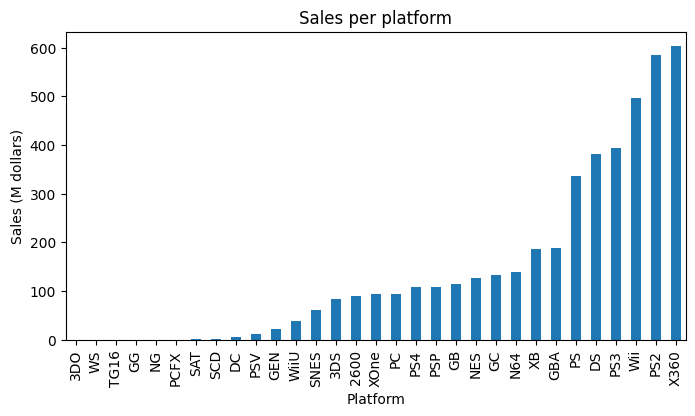

In [49]:
# Group by 'platform' and obtain the total sales
sales_per_platform = df.groupby('platform')['sales'].sum()
sales_per_platform = sales_per_platform.sort_values()

# Plot 'sales_per_platform' considering all platforms
sales_per_platform.plot(kind='bar', figsize=[8,4],
                        title='Sales per platform',
                        xlabel='Platform', ylabel='Sales (M dollars)')
plt.show()

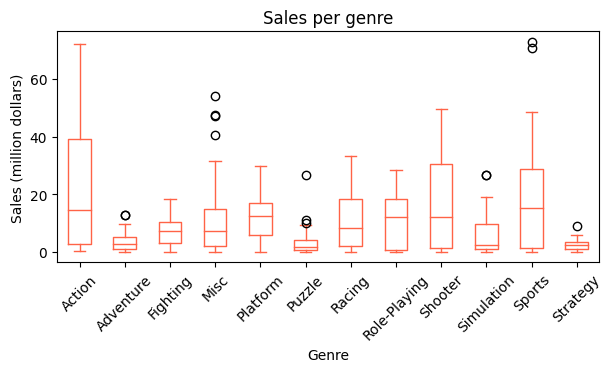

In [50]:
# Plot 'sales_per_genre' considering main group of genres
sales_per_genre.plot(kind='box', figsize=[7,3], title='Sales per genre',
    xlabel='Genre', ylabel='Sales (million dollars)', color='tomato', rot=45)
plt.show()

## Merging

In [51]:
# DataFrames merging
# df2 = df1.merge(df_2,on='customerID',how='left')